In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("census2011.csv")

In [70]:
print("Dataset Preview:")
print(df.head())
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"Total Districts: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

Dataset Preview:
   Ranking                    District        State  Population   Growth  \
0        1                       Thane  Maharashtra  11,060,148  36.01 %   
1        2  North Twenty Four Parganas  West Bengal  10,009,781  12.04 %   
2        3                   Bangalore    Karnataka   9,621,551  47.18 %   
3        4                        Pune  Maharashtra   9,429,408  30.37 %   
4        5             Mumbai Suburban  Maharashtra   9,356,962   8.29 %   

   Sex-Ratio  Literacy  
0        886     84.53  
1        955     84.06  
2        916     87.67  
3        915     86.15  
4        860     89.91  

📊 Dataset Shape: (610, 7)
Total Districts: 610
Total Features: 7


In [71]:
#Data Cleaning
df['Population_Clean'] = df['Population'].str.replace(',', '').astype(float)
df['Growth_Clean'] = df['Growth'].str.replace('%', '').str.strip().astype(float)
print("Data cleaning completed!")
print("\nCleaned Data Preview:")
print(df[['District', 'Population_Clean', 'Growth_Clean', 'Sex-Ratio', 'Literacy']].head())
print("\nData Types After Cleaning:")
print(df[['Population_Clean', 'Growth_Clean', 'Sex-Ratio', 'Literacy']].dtypes)


Data cleaning completed!

Cleaned Data Preview:
                     District  Population_Clean  Growth_Clean  Sex-Ratio  \
0                       Thane        11060148.0         36.01        886   
1  North Twenty Four Parganas        10009781.0         12.04        955   
2                   Bangalore         9621551.0         47.18        916   
3                        Pune         9429408.0         30.37        915   
4             Mumbai Suburban         9356962.0          8.29        860   

   Literacy  
0     84.53  
1     84.06  
2     87.67  
3     86.15  
4     89.91  

Data Types After Cleaning:
Population_Clean    float64
Growth_Clean        float64
Sex-Ratio             int64
Literacy            float64
dtype: object


In [72]:
#Check for Missing Values and Handle Them
print("Missing Values Check:")
print(df[['Population_Clean', 'Growth_Clean', 'Sex-Ratio', 'Literacy']].isnull().sum())
df_clean = df[['District', 'State', 'Population_Clean', 'Growth_Clean', 'Sex-Ratio', 'Literacy']].dropna()
print(f"\n Dataset after cleaning: {df_clean.shape[0]} districts")

Missing Values Check:
Population_Clean    0
Growth_Clean        0
Sex-Ratio           0
Literacy            0
dtype: int64

 Dataset after cleaning: 610 districts


In [73]:
#Feature Selection and Preparation for Linear Regression
# Let's use Population, Growth, and Sex-Ratio to predict Literacy
feature_cols = ['Population_Clean', 'Growth_Clean', 'Sex-Ratio']
X = df_clean[feature_cols].values
y = df_clean['Literacy'].values
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)
print("\nFeature Statistics:")
print(pd.DataFrame(X, columns=feature_cols).describe())


Feature Matrix Shape: (610, 3)
Target Vector Shape: (610,)

Feature Statistics:
       Population_Clean  Growth_Clean    Sex-Ratio
count      6.100000e+02    610.000000   610.000000
mean       1.845019e+06     19.439852   944.914754
std        1.566814e+06     14.996064    61.247694
min        8.004000e+03    -21.570000   534.000000
25%        7.754178e+05     12.357500   905.000000
50%        1.498161e+06     17.325000   948.000000
75%        2.423572e+06     23.190000   982.000000
max        1.106015e+07    131.810000  1184.000000


In [74]:
#Feature Scaling (For Gradient Descent)
# Standardize features to have mean=0 and std=1

def standardize_features(X):
    """Standardize features using Z-score normalization"""
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_scaled = (X - mean) / std
    return X_scaled, mean, std

X_scaled, X_mean, X_std = standardize_features(X)
print("Features standardized!")
print("\nScaled Feature Statistics:")
print(f"Mean: {np.mean(X_scaled, axis=0)}")
print(f"Std: {np.std(X_scaled, axis=0)}")


Features standardized!

Scaled Feature Statistics:
Mean: [ 0.00000000e+00 -1.98020107e-16  6.15900773e-16]
Std: [1. 1. 1.]


In [75]:
# Cell 7: Train-Validation-Test Split (70%-15%-15%)
np.random.seed(42)  # For reproducibility
n = len(X_scaled)
indices = np.random.permutation(n)
# Calculate split points
train_end = int(0.7 * n)
val_end = int(0.85 * n)
train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]
# Create splits
X_train, y_train = X_scaled[train_idx], y[train_idx]
X_val, y_val = X_scaled[val_idx], y[val_idx]
X_test, y_test = X_scaled[test_idx], y[test_idx]
print("Data Split Completed:")
print(f"Training set: {len(X_train)} samples ({len(X_train)/n*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/n*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/n*100:.1f}%)")


Data Split Completed:
Training set: 427 samples (70.0%)
Validation set: 91 samples (14.9%)
Test set: 92 samples (15.1%)


In [76]:
# Cell 8: Add Bias Term (Intercept)
X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_val_b = np.c_[np.ones(X_val.shape[0]), X_val]
X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]
print("Bias term added!")
print(f"New feature shape with bias: {X_train_b.shape}")


Bias term added!
New feature shape with bias: (427, 4)


In [77]:
#Batch Gradient Descent Implementation
def compute_mse(X, y, theta):
    """Compute Mean Squared Error"""
    m = len(y)
    predictions = X.dot(theta)
    mse = (1/(2*m)) * np.sum((predictions - y)**2)
    return mse

def batch_gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    """Batch Gradient Descent for Linear Regression updates weights using ALL training samples at once"""
    m, n = X.shape
    theta = np.zeros(n)  # Initialize weights
    loss_history = []
    
    for iteration in range(n_iterations):
        # Compute predictions
        predictions = X.dot(theta)
        # Compute gradients (using all samples)
        gradients = (1/m) * X.T.dot(predictions - y)        
        # Update weights
        theta = theta - learning_rate * gradients        
        # Store loss
        loss = compute_mse(X, y, theta)
        loss_history.append(loss)   
        # Print progress every 100 iterations
        if iteration % 100 == 0:
            print(f"Iteration {iteration}: Loss = {loss:.4f}")    
    return theta, loss_history

print("Training Batch Gradient Descent...")
theta_batch, loss_history_batch = batch_gradient_descent(
    X_train_b, y_train, 
    learning_rate=0.01, 
    n_iterations=1000
)

print("\nTraining Complete!")
print(f"\nLearned Weights (Batch GD):")
print(f"Bias (θ0): {theta_batch[0]:.4f}")
for i, feature in enumerate(feature_cols):
    print(f"{feature} (θ{i+1}): {theta_batch[i+1]:.4f}")


Training Batch Gradient Descent...
Iteration 0: Loss = 2625.1551
Iteration 100: Loss = 399.4164
Iteration 200: Loss = 100.6185
Iteration 300: Loss = 60.4349
Iteration 400: Loss = 55.0226
Iteration 500: Loss = 54.2925
Iteration 600: Loss = 54.1939
Iteration 700: Loss = 54.1806
Iteration 800: Loss = 54.1788
Iteration 900: Loss = 54.1785

Training Complete!

Learned Weights (Batch GD):
Bias (θ0): 72.4436
Population_Clean (θ1): 0.4891
Growth_Clean (θ2): -1.3616
Sex-Ratio (θ3): 1.1807


In [78]:
#Stochastic Gradient Descent Implementation

def stochastic_gradient_descent(X, y, learning_rate=0.01, n_epochs=50):
    """Stochastic Gradient Descent for Linear Regression updates weights after EACH individual sample"""
    m, n = X.shape
    theta = np.zeros(n)
    loss_history = []
    
    for epoch in range(n_epochs):
        # Shuffle the data
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]        
        # Update for each sample
        for i in range(m):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]            
            # Compute prediction for single sample
            prediction = xi.dot(theta)            
            # Compute gradient for single sample
            gradient = xi.T.dot(prediction - yi)            
            # Update weights
            theta = theta - learning_rate * gradient.flatten()        
        # Compute loss after each epoch
        loss = compute_mse(X, y, theta)
        loss_history.append(loss)        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Loss = {loss:.4f}")    
    return theta, loss_history

print("Training Stochastic Gradient Descent...")
theta_sgd, loss_history_sgd = stochastic_gradient_descent(
    X_train_b, y_train, 
    learning_rate=0.01, 
    n_epochs=50
)
print("\nTraining Complete!")
print(f"\nLearned Weights (SGD):")
print(f"Bias (θ0): {theta_sgd[0]:.4f}")
for i, feature in enumerate(feature_cols):
    print(f"{feature} (θ{i+1}): {theta_sgd[i+1]:.4f}")


Training Stochastic Gradient Descent...
Epoch 0: Loss = 55.5938
Epoch 10: Loss = 55.9622
Epoch 20: Loss = 55.4388
Epoch 30: Loss = 55.1720
Epoch 40: Loss = 56.3865

Training Complete!

Learned Weights (SGD):
Bias (θ0): 72.1600
Population_Clean (θ1): -0.0157
Growth_Clean (θ2): -1.3488
Sex-Ratio (θ3): 0.3018


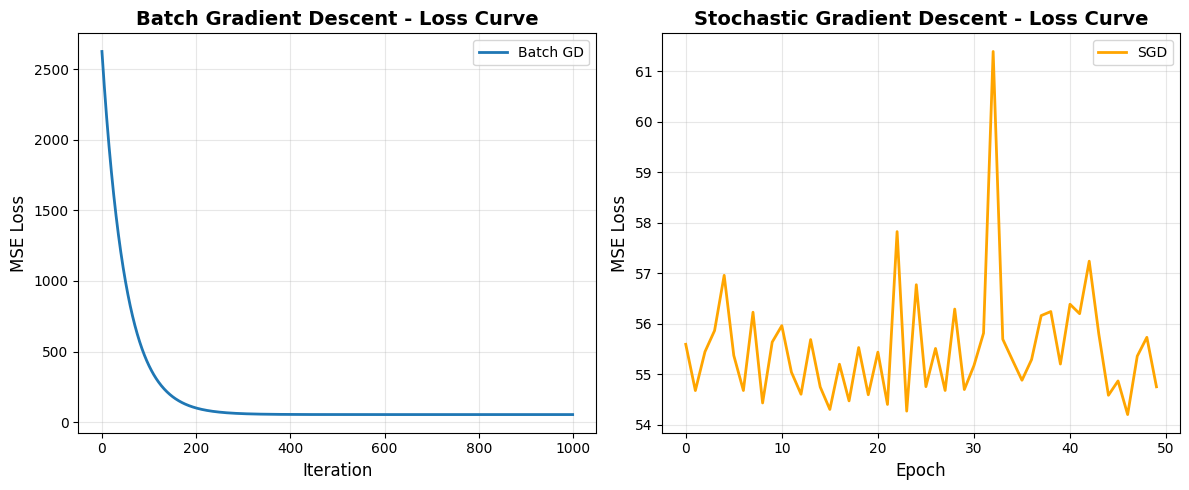

Loss curves plotted successfully!


In [79]:
#Plot Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history_batch, label='Batch GD', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Batch Gradient Descent - Loss Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(loss_history_sgd, label='SGD', color='orange', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Stochastic Gradient Descent - Loss Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('LossCurve.png')
plt.show()
print("Loss curves plotted successfully!")


In [80]:
#Evaluation Metrics Implementation

def evaluate_model(X, y, theta, model_name):
    """Calculate evaluation metrics"""
    predictions = X.dot(theta)    
    # MSE
    mse = np.mean((predictions - y)**2)    
    # RMSE
    rmse = np.sqrt(mse)    
    # MAE
    mae = np.mean(np.abs(predictions - y))    
    # R² Score
    ss_res = np.sum((y - predictions)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - Evaluation Metrics")
    print(f"MSE (Mean Squared Error):     {mse:.4f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"MAE (Mean Absolute Error):     {mae:.4f}")
    print(f"R² Score:                      {r2:.4f}")
    print(f"{'='*60}")    
    return predictions, mse, rmse, mae, r2

# Evaluate both models on test set
print("\nEVALUATING MODELS ON TEST SET")
y_pred_batch, mse_batch, rmse_batch, mae_batch, r2_batch = evaluate_model(
    X_test_b, y_test, theta_batch, "Batch Gradient Descent"
)
y_pred_sgd, mse_sgd, rmse_sgd, mae_sgd, r2_sgd = evaluate_model(
    X_test_b, y_test, theta_sgd, "Stochastic Gradient Descent"
)



EVALUATING MODELS ON TEST SET

Batch Gradient Descent - Evaluation Metrics
MSE (Mean Squared Error):     91.3167
RMSE (Root Mean Squared Error): 9.5560
MAE (Mean Absolute Error):     7.8296
R² Score:                      0.0859

Stochastic Gradient Descent - Evaluation Metrics
MSE (Mean Squared Error):     95.6693
RMSE (Root Mean Squared Error): 9.7811
MAE (Mean Absolute Error):     7.9462
R² Score:                      0.0424


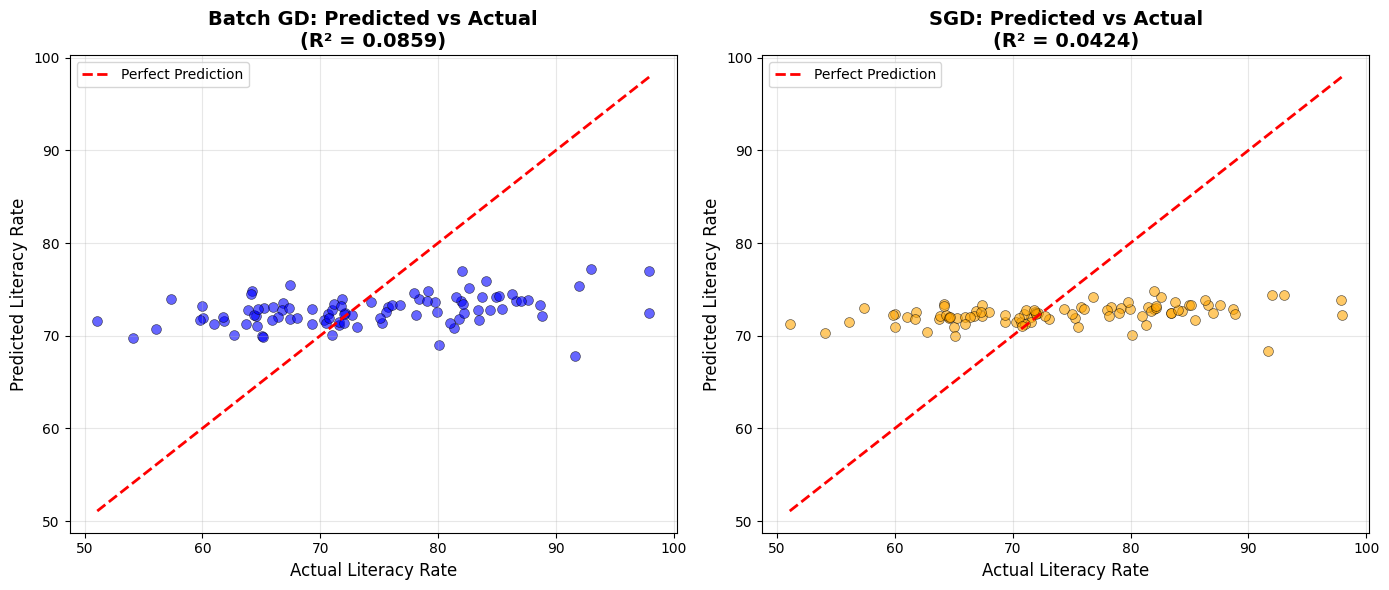

Prediction plots created successfully!


In [81]:
#Predicted vs Actual Scatter Plot
plt.figure(figsize=(14, 6))
# Batch GD
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_batch, alpha=0.6, s=50, color='blue', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Literacy Rate', fontsize=12)
plt.ylabel('Predicted Literacy Rate', fontsize=12)
plt.title(f'Batch GD: Predicted vs Actual\n(R² = {r2_batch:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# SGD
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sgd, alpha=0.6, s=50, color='orange', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Literacy Rate', fontsize=12)
plt.ylabel('Predicted Literacy Rate', fontsize=12)
plt.title(f'SGD: Predicted vs Actual\n(R² = {r2_sgd:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Batch_GD.png')
plt.show()
print("Prediction plots created successfully!")


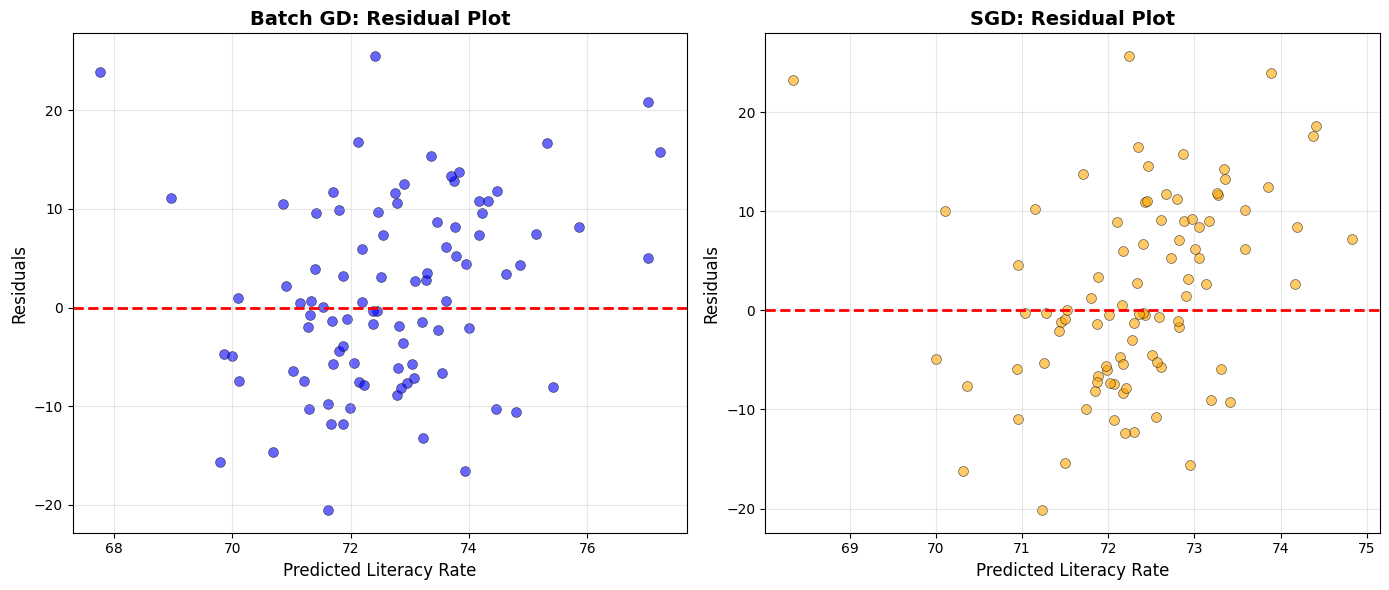

Residual plots created successfully!


In [82]:
#Residual Analysis
residuals_batch = y_test - y_pred_batch
residuals_sgd = y_test - y_pred_sgd
plt.figure(figsize=(14, 6))

# Batch GD Residuals
plt.subplot(1, 2, 1)
plt.scatter(y_pred_batch, residuals_batch, alpha=0.6, s=50, color='blue', edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Literacy Rate', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Batch GD: Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# SGD Residuals
plt.subplot(1, 2, 2)
plt.scatter(y_pred_sgd, residuals_sgd, alpha=0.6, s=50, color='orange', edgecolors='k', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Literacy Rate', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('SGD: Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Residual plots created successfully!")


Literacy categories created!

Class Distribution:
Literacy_Category
Low       148
Medium    311
High      151
Name: count, dtype: int64


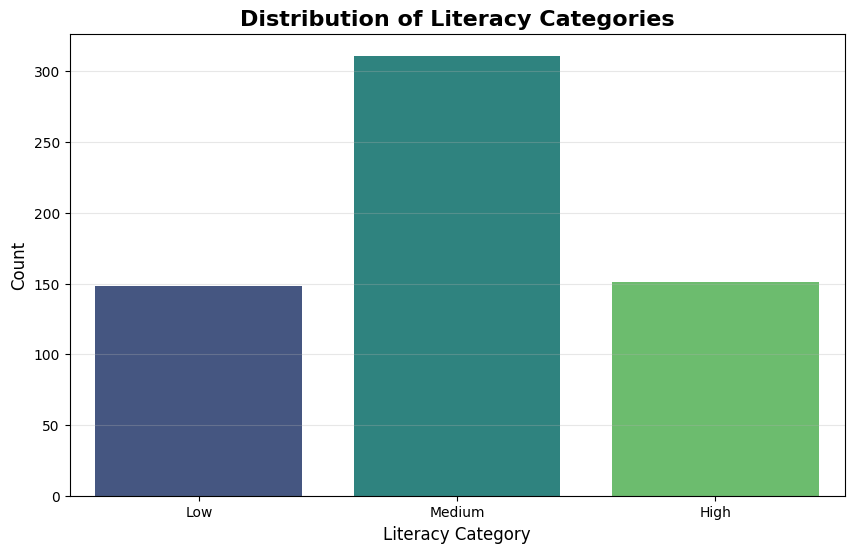

In [83]:
#Create Categorical Target Variable

# Create literacy categories: Low (<65%), Medium (65-80%), High (>80%)
df_clean['Literacy_Category'] = pd.cut(
    df_clean['Literacy'], 
    bins=[0, 65, 80, 100], 
    labels=['Low', 'Medium', 'High']
)
print("Literacy categories created!")
print("\nClass Distribution:")
print(df_clean['Literacy_Category'].value_counts().sort_index())

# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Literacy_Category', hue='Literacy_Category', palette='viridis', legend=False)
plt.title('Distribution of Literacy Categories', fontsize=16, fontweight='bold')
plt.xlabel('Literacy Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('literacy_category_distribution.png')
plt.show()



In [84]:
#Prepare Data for KNN Classification
X_knn = df_clean[['Population_Clean', 'Growth_Clean', 'Sex-Ratio']].values
# Target labels (convert to numeric: Low=0, Medium=1, High=2)
y_knn = df_clean['Literacy_Category'].map({'Low': 0, 'Medium': 1, 'High': 2}).values
# Standardize features
X_knn_scaled, X_knn_mean, X_knn_std = standardize_features(X_knn)
print("Feature Matrix Shape:", X_knn_scaled.shape)
print("Target Vector Shape:", y_knn.shape)
print("\nClass encoding: Low=0, Medium=1, High=2")


Feature Matrix Shape: (610, 3)
Target Vector Shape: (610,)

Class encoding: Low=0, Medium=1, High=2


In [85]:
#Train-Test Split for KNN (80%-20%)
np.random.seed(42)
n_knn = len(X_knn_scaled)
indices_knn = np.random.permutation(n_knn)
train_size = int(0.8 * n_knn)
train_idx_knn = indices_knn[:train_size]
test_idx_knn = indices_knn[train_size:]
X_train_knn = X_knn_scaled[train_idx_knn]
y_train_knn = y_knn[train_idx_knn]
X_test_knn = X_knn_scaled[test_idx_knn]
y_test_knn = y_knn[test_idx_knn]
print("KNN Data Split:")
print(f"Training set: {len(X_train_knn)} samples")
print(f"Test set: {len(X_test_knn)} samples")


KNN Data Split:
Training set: 488 samples
Test set: 122 samples


In [86]:
#KNN Algorithm Implementation

def euclidean_distance(x1, x2):
    """Calculate Euclidean distance between two points"""
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, x_test, k=3):
    """Predict class for a single test sample using KNN"""
    # Calculate distances from test point to all training points
    distances = []
    for i in range(len(X_train)):
        dist = euclidean_distance(x_test, X_train[i])
        distances.append((dist, y_train[i]))    
    # Sort by distance and get k nearest neighbors
    distances.sort(key=lambda x: x[0])
    k_nearest = distances[:k]    
    # Get labels of k nearest neighbors
    k_nearest_labels = [label for (_, label) in k_nearest]    
    # Return most common label (majority vote)
    return max(set(k_nearest_labels), key=k_nearest_labels.count)

def knn_classifier(X_train, y_train, X_test, k=3):
    """Predict classes for all test samples"""
    predictions = []
    for i in range(len(X_test)):
        pred = knn_predict(X_train, y_train, X_test[i], k)
        predictions.append(pred)
        if (i + 1) % 20 == 0:
            print(f"Processed {i+1}/{len(X_test)} samples...")    
    return np.array(predictions)
print("KNN Algorithm implemented!")


KNN Algorithm implemented!


In [87]:
#Train KNN with Different K Values
k_values = [3, 5, 7]
results = {}

for k in k_values:
    print(f"Training KNN with k={k}") 
    # Make predictions
    y_pred_knn = knn_classifier(X_train_knn, y_train_knn, X_test_knn, k=k)    
    # Calculate accuracy
    accuracy = np.mean(y_pred_knn == y_test_knn)    
    # Store results
    results[k] = {
        'predictions': y_pred_knn,
        'accuracy': accuracy
    }    
    print(f"\nAccuracy with k={k}: {accuracy*100:.2f}%")

print("Summary of Results:")
for k, res in results.items():
    print(f"k={k}: Accuracy = {res['accuracy']*100:.2f}%")


Training KNN with k=3
Processed 20/122 samples...
Processed 40/122 samples...
Processed 60/122 samples...
Processed 80/122 samples...
Processed 100/122 samples...
Processed 120/122 samples...

Accuracy with k=3: 50.00%
Training KNN with k=5
Processed 20/122 samples...
Processed 40/122 samples...
Processed 60/122 samples...
Processed 80/122 samples...
Processed 100/122 samples...
Processed 120/122 samples...

Accuracy with k=5: 54.10%
Training KNN with k=7
Processed 20/122 samples...
Processed 40/122 samples...
Processed 60/122 samples...
Processed 80/122 samples...
Processed 100/122 samples...
Processed 120/122 samples...

Accuracy with k=7: 50.82%
Summary of Results:
k=3: Accuracy = 50.00%
k=5: Accuracy = 54.10%
k=7: Accuracy = 50.82%



Confusion Matrix for k=3:
[[11 15  2]
 [14 39  6]
 [ 4 20 11]]
Saved plot as confusionMatrix_k3.png


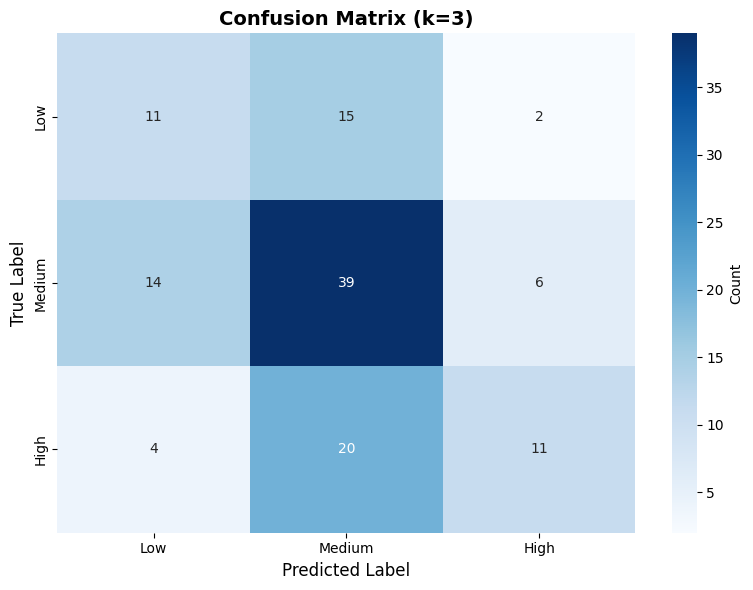


Confusion Matrix for k=5:
[[10 15  3]
 [11 44  4]
 [ 2 21 12]]
Saved plot as confusionMatrix_k5.png


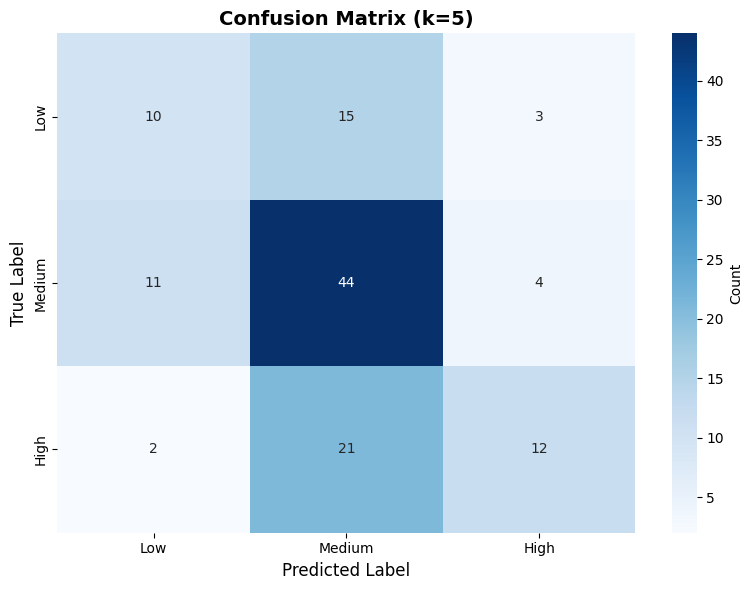


Confusion Matrix for k=7:
[[10 16  2]
 [11 45  3]
 [ 4 24  7]]
Saved plot as confusionMatrix_k7.png


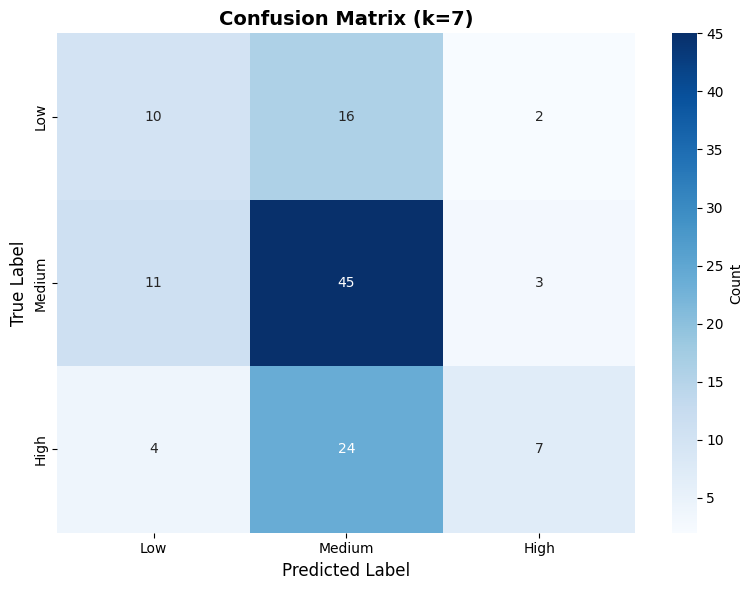

In [88]:
#Confusion Matrix Calculation

def confusion_matrix_manual(y_true, y_pred, n_classes=3):
    """ Calculate confusion matrix manually"""
    cm = np.zeros((n_classes, n_classes), dtype=int)    
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1    
    return cm

def plot_confusion_matrix(cm, k_value):
    """ Plot confusion matrix as heatmap"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix (k={k_value})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    # Create a unique filename for each plot
    filename = f'confusionMatrix_k{k_value}.png'
    plt.savefig(filename)
    print(f"Saved plot as {filename}")
    plt.show()

# Plot confusion matrices for all k values
for k in k_values:
    cm = confusion_matrix_manual(y_test_knn, results[k]['predictions'])
    print(f"\nConfusion Matrix for k={k}:")
    print(cm)
    plot_confusion_matrix(cm, k)


In [89]:
#K-Fold Cross-Validation Implementation

def k_fold_cross_validation(X, y, k_neighbors=5, n_folds=5):
    """Perform K-Fold Cross-Validation manually"""
    n_samples = len(X)
    fold_size = n_samples // n_folds
    indices = np.arange(n_samples)
    np.random.shuffle(indices)    
    fold_accuracies = []
    
    for fold in range(n_folds):
        print(f"\nFold {fold + 1}/{n_folds}")   
        # Create validation indices for this fold
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size if fold < n_folds - 1 else n_samples        
        val_indices = indices[val_start:val_end]
        train_indices = np.concatenate([indices[:val_start], indices[val_end:]])
        
        # Split data
        X_train_fold = X[train_indices]
        y_train_fold = y[train_indices]
        X_val_fold = X[val_indices]
        y_val_fold = y[val_indices]        
        # Train and predict
        y_pred_fold = knn_classifier(X_train_fold, y_train_fold, X_val_fold, k=k_neighbors)        
        # Calculate accuracy
        accuracy = np.mean(y_pred_fold == y_val_fold)
        fold_accuracies.append(accuracy)        
        print(f"Accuracy: {accuracy*100:.2f}%")    
    return fold_accuracies

# Perform 5-fold cross-validation
print("Performing 5-Fold Cross-Validation with k=5")
fold_accuracies = k_fold_cross_validation(X_train_knn, y_train_knn, k_neighbors=5, n_folds=5)
print("Cross-Validation Results:")
print(f"Fold Accuracies: {[f'{acc*100:.2f}%' for acc in fold_accuracies]}")
print(f"Mean Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies)*100:.2f}%")


Performing 5-Fold Cross-Validation with k=5

Fold 1/5
Processed 20/97 samples...
Processed 40/97 samples...
Processed 60/97 samples...
Processed 80/97 samples...
Accuracy: 58.76%

Fold 2/5
Processed 20/97 samples...
Processed 40/97 samples...
Processed 60/97 samples...
Processed 80/97 samples...
Accuracy: 59.79%

Fold 3/5
Processed 20/97 samples...
Processed 40/97 samples...
Processed 60/97 samples...
Processed 80/97 samples...
Accuracy: 53.61%

Fold 4/5
Processed 20/97 samples...
Processed 40/97 samples...
Processed 60/97 samples...
Processed 80/97 samples...
Accuracy: 58.76%

Fold 5/5
Processed 20/100 samples...
Processed 40/100 samples...
Processed 60/100 samples...
Processed 80/100 samples...
Processed 100/100 samples...
Accuracy: 55.00%
Cross-Validation Results:
Fold Accuracies: ['58.76%', '59.79%', '53.61%', '58.76%', '55.00%']
Mean Accuracy: 57.19%
Std Deviation: 2.42%


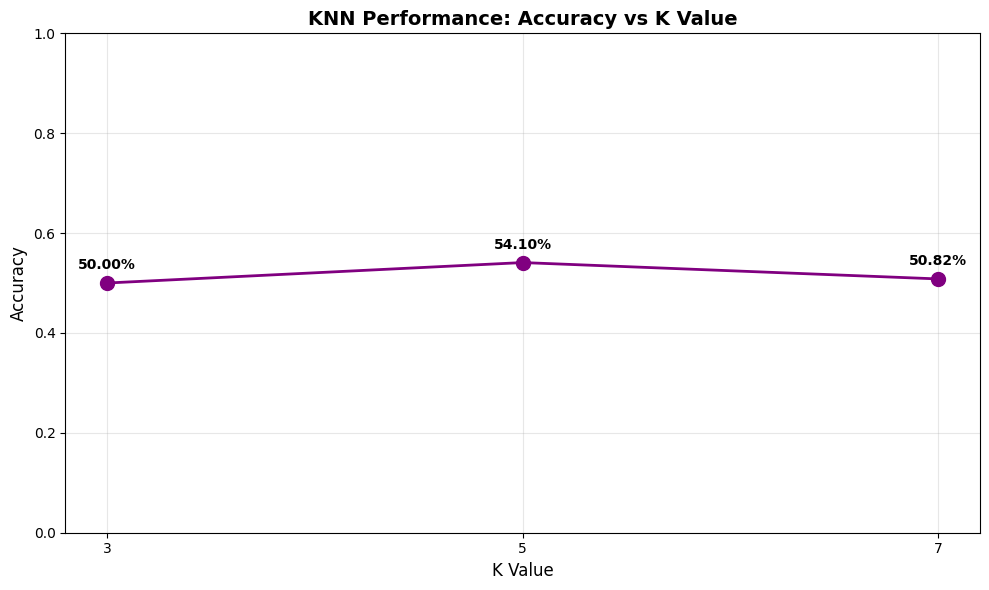

K-value comparison plot created!


In [90]:
#Compare Different K Values
accuracies = [results[k]['accuracy'] for k in k_values]
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=10, color='purple')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Performance: Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

for k, acc in zip(k_values, accuracies):
    plt.annotate(f'{acc*100:.2f}%', 
                xy=(k, acc), 
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold')
plt.tight_layout()
plt.show()
print("K-value comparison plot created!")
